In [1]:
import pandas as pd
import pickle
import numpy as np
import tensorflow as tf
import keras
from keras import backend as K
from keras.models import load_model, Model
from keras.layers import Flatten, Dense, Dropout, Activation, Input, LSTM, Reshape, Conv2D, MaxPooling2D
from keras.optimizers import Adam
from keras.layers import LeakyReLU
#!pip install np_utils
from keras import utils

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

RANDOM_SEED = 0

# set random seeds
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## Mounting Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing Dataset

In [3]:
import os
import zipfile

# Define the target directory in Google Drive for the unzipped files
UNZIPPED_DATA_DIR = '/content/drive/MyDrive/LOBCNN/newdata/'

# Check if the unzipped data directory already exists and contains files
if not os.path.exists(UNZIPPED_DATA_DIR) or not os.listdir(UNZIPPED_DATA_DIR):
    print(f"Data not found in {UNZIPPED_DATA_DIR}. Attempting to download and unzip.")

    # Create the target directory if it doesn't exist
    os.makedirs(UNZIPPED_DATA_DIR, exist_ok=True)

    # Define a temporary path for the downloaded zip file in /content/
    TEMP_ZIP_PATH = '/content/data.zip'

    # Download the data.zip file to /content/
    !wget -q https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip -O {TEMP_ZIP_PATH}

    # Unzip the downloaded file directly into the target directory in Google Drive
    with zipfile.ZipFile(TEMP_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(UNZIPPED_DATA_DIR)

    # Optionally, remove the temporary zip file to save space
    os.remove(TEMP_ZIP_PATH)

    print('Data downloaded and unzipped to Google Drive.')
else:
    print('Data already existed and is ready in Google Drive.')

Data already existed and is ready in Google Drive.


# Functions for pre-processing:


In [4]:
def prepare_x(data):
    df1 = data[:40, :].T
    return np.array(df1)

def get_label(data):
    lob = data[-5:, :].T
    return lob

def data_classification(X, Y, T):
    [N, D] = X.shape
    df = np.array(X)
    dY = np.array(Y)
    dataY = dY[T - 1:N]
    dataX = np.zeros((N - T + 1, T, D))
    for i in range(T, N + 1):
        dataX[i - T] = df[i - T:i, :]
    return dataX.reshape(dataX.shape + (1,)), dataY

def prepare_x_y(data, k, T):
    x = prepare_x(data)
    y = get_label(data)
    x, y = data_classification(x, y, T=T)
    y = y[:,k] - 1
    y = utils.to_categorical(y, 3)
    return x, y


def macro_f1(y_true, y_pred):
    """Macro-averaged F1 score for multi-class classification."""
    y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
    y_true = tf.cast(tf.argmax(y_true, axis=-1), tf.int32)

    f1_scores = []
    for i in range(3):
        y_true_i = tf.cast(tf.equal(y_true, i), tf.float32)
        y_pred_i = tf.cast(tf.equal(y_pred, i), tf.float32)

        tp = tf.reduce_sum(y_true_i * y_pred_i)
        fp = tf.reduce_sum((1.0 - y_true_i) * y_pred_i)
        fn = tf.reduce_sum(y_true_i * (1.0 - y_pred_i))

        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())
        f1 = 2.0 * precision * recall / (precision + recall + tf.keras.backend.epsilon())
        f1_scores.append(f1)

    return tf.reduce_mean(tf.stack(f1_scores))

In [5]:
dec_data = np.loadtxt(os.path.join(UNZIPPED_DATA_DIR, 'Train_Dst_NoAuction_DecPre_CF_7.txt'))
dec_train = dec_data[:, :int(np.floor(dec_data.shape[1] * 0.8))]
dec_val = dec_data[:, int(np.floor(dec_data.shape[1] * 0.8)):]

dec_test1 = np.loadtxt(os.path.join(UNZIPPED_DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_7.txt'))
dec_test2 = np.loadtxt(os.path.join(UNZIPPED_DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_8.txt'))
dec_test3 = np.loadtxt(os.path.join(UNZIPPED_DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_9.txt'))
dec_test = np.hstack((dec_test1, dec_test2, dec_test3))

k = 4 # which prediction horizon
T = 100 # the length of a single input
n_hiddens = 64

trainX_CNN, trainY_CNN = prepare_x_y(dec_train, k, T)
valX_CNN, valY_CNN = prepare_x_y(dec_val, k, T)
testX_CNN, testY_CNN = prepare_x_y(dec_test, k, T)

print(trainX_CNN.shape, trainY_CNN.shape)
print(valX_CNN.shape, valY_CNN.shape)
print(testX_CNN.shape, testY_CNN.shape)

(656217, 100, 40, 1) (656217, 3)
(163981, 100, 40, 1) (163981, 3)
(242433, 100, 40, 1) (242433, 3)


# Model

In [6]:

from keras.models import Model
from keras.layers import Input, LSTM, Dense, Dropout, Reshape

def create_lstm1(T, NF, number_of_lstm):
    input_lmd = Input(shape=(T, NF))

    # build the LSTM layers
    lstm_layer = LSTM(number_of_lstm, return_sequences=True)(input_lmd)
    lstm_layer = LSTM(number_of_lstm, return_sequences=True)(lstm_layer)

    # reshape for compatibility with dense layer
    lstm_reshape = Reshape((T * number_of_lstm,))(lstm_layer)
    lstm_reshape = Dropout(0.2)(lstm_reshape, training=True)

    # build the output layer
    out = Dense(3, activation='softmax')(lstm_reshape)

    model = Model(inputs=input_lmd, outputs=out)
    adam = keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy', macro_f1])

    return model

# Assuming trainX_CNN.shape[1] is T, trainX_CNN.shape[2] is NF, and n_hiddens is the number of LSTM units
lstm1 = create_lstm1(trainX_CNN.shape[1], trainX_CNN.shape[2], n_hiddens)
lstm1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │        19,203 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,107 (309.01 KB)

 Trainable params: 79,107 (309.01 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
%%time
checkpoint_filepath = f'/content/drive/MyDrive/LOBCNN/models/LSTM_1_newdata_{RANDOM_SEED}.weights.h5'

if os.path.exists(checkpoint_filepath):
    lstm1.load_weights(checkpoint_filepath)
    print("Loaded saved weights.")
else:
    print("No saved weights found. Starting training from scratch.")
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
        monitor='val_macro_f1',
        mode='max',
        save_best_only=True)
    lstm1.fit(trainX_CNN, trainY_CNN, validation_data=(valX_CNN, valY_CNN),
              epochs=200, batch_size=128, verbose=1, callbacks=[model_checkpoint_callback])

No saved weights found. Starting training from scratch.
Epoch 1/200
5127/5127 ━━━━━━━━━━━━━━━━━━━━ 78s 15ms/step - accuracy: 0.6090 - loss: 0.8153 - macro_f1: 0.2721 - val_accuracy: 0.5580 - val_loss: 0.8634 - val_macro_f1: 0.2584
Epoch 2/200
5127/5127 ━━━━━━━━━━━━━━━━━━━━ 71s 14ms/step - accuracy: 0.6899 - loss: 0.7102 - macro_f1: 0.4389 - val_accuracy: 0.6682 - val_loss: 0.7526 - val_macro_f1: 0.4168
Epoch 3/200
5127/5127 ━━━━━━━━━━━━━━━━━━━━ 70s 14ms/step - accuracy: 0.7592 - loss: 0.6270 - macro_f1: 0.5161 - val_accuracy: 0.7173 - val_loss: 0.6949 - val_macro_f1: 0.4651
Epoch 4/200
5127/5127 ━━━━━━━━━━━━━━━━━━━━ 70s 14ms/step - accuracy: 0.7948 - loss: 0.5772 - macro_f1: 0.5487 - val_accuracy: 0.7417 - val_loss: 0.6629 - val_macro_f1: 0.4853
Epoch 5/200
5127/5127 ━━━━━━━━━━━━━━━━━━━━ 70s 14ms/step - accuracy: 0.8096 - loss: 0.5462 - macro_f1: 0.5637 - val_accuracy: 0.7415 - val_loss: 0.6617 - val_macro_f1: 0.4885
Epoch 6/200
5127/5127 ━━━━━━━━━━━━━━━━━━━━ 70s 14ms/step - accuracy: 

In [8]:
print(accuracy_score(np.argmax(testY_CNN, axis=1), np.argmax(lstm1.predict(testX_CNN), axis=1)))

7577/7577 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step
0.6806622860749155


In [9]:
print(classification_report(np.argmax(testY_CNN, axis=1), np.argmax(lstm1.predict(testX_CNN), axis=1)))

7577/7577 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step
              precision    recall  f1-score   support

           0       0.68      0.67      0.68     86783
           1       0.06      0.13      0.08     12400
           2       0.82      0.74      0.78    143250

    accuracy                           0.68    242433
   macro avg       0.52      0.51      0.51    242433
weighted avg       0.73      0.68      0.70    242433



7577/7577 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step


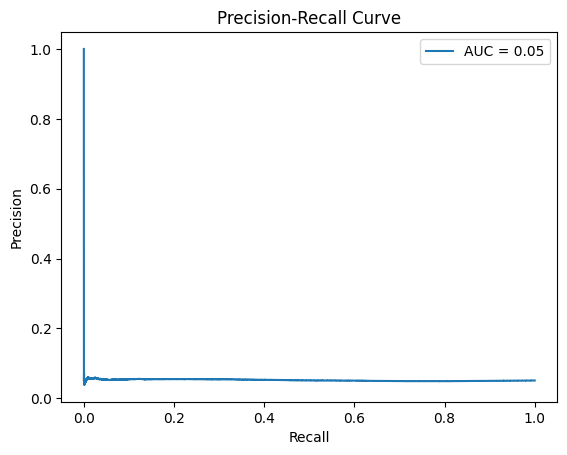

In [10]:
from sklearn.metrics import precision_recall_curve, auc

# Get predicted probabilities for the positive class
y_pred_proba = lstm1.predict(testX_CNN)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(testY_CNN[:, 1], y_pred_proba)

# Calculate area under the curve
auc_score = auc(recall, precision)

# Plot the precision-recall curve
plt.plot(recall, precision, label=f'AUC = {auc_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [11]:
print(accuracy_score(np.argmax(trainY_CNN, axis=1), np.argmax(lstm1.predict(trainX_CNN), axis=1)))

20507/20507 ━━━━━━━━━━━━━━━━━━━━ 76s 4ms/step
0.9157641450922485


In [12]:
print(classification_report(np.argmax(trainY_CNN, axis=1), np.argmax(lstm1.predict(trainX_CNN), axis=1)))

20507/20507 ━━━━━━━━━━━━━━━━━━━━ 78s 4ms/step
              precision    recall  f1-score   support

           0       0.93      0.86      0.89    223455
           1       0.84      0.70      0.77     34329
           2       0.92      0.97      0.94    398433

    accuracy                           0.92    656217
   macro avg       0.89      0.84      0.87    656217
weighted avg       0.92      0.92      0.91    656217



20507/20507 ━━━━━━━━━━━━━━━━━━━━ 77s 4ms/step


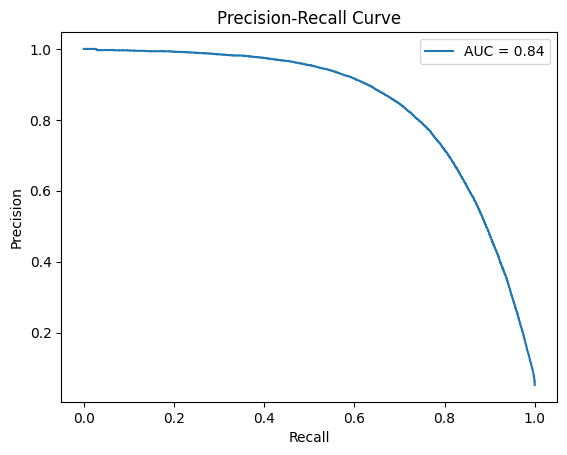

In [13]:
from sklearn.metrics import precision_recall_curve, auc

# Get predicted probabilities for the positive class
y_pred_proba = lstm1.predict(trainX_CNN)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(trainY_CNN[:, 1], y_pred_proba)

# Calculate area under the curve
auc_score = auc(recall, precision)

# Plot the precision-recall curve
plt.plot(recall, precision, label=f'AUC = {auc_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [14]:
""" TRADING STRATEGY BEFORE ATTACK ON TEST DATA"""
import numpy as np
import pandas as pd

print("Getting predictions...")
train_predictions = lstm1.predict(testX_CNN)

# First define our strategy function
def implement_fi2010_strategy(predictions, dec_data, budget=100, prob_threshold=0.5, k=4, alpha=0.001):
    # Get average ask and bid prices
    ask_prices = dec_data[0, :]
    bid_prices = dec_data[2, :]
    mid_prices = (ask_prices + bid_prices) / 2

    min_length = min(len(predictions), len(mid_prices) - k)
    predictions = predictions[:min_length]

    trades_info = []

    for i in range(k, min_length):
        m_plus = np.mean(mid_prices[i+1:i+k+1])

        lt = (m_plus - mid_prices[i]) / mid_prices[i]

        pred_class = np.argmax([predictions[i, 0], predictions[i, 1], predictions[i, 2]])
        max_prob = np.max([predictions[i, 0], predictions[i, 1], predictions[i, 2]])

        if max_prob > prob_threshold and pred_class != 1:
            actual_direction = 1 if lt > alpha else (-1 if lt < -alpha else 0)


            if pred_class == 2:
                shares = budget / mid_prices[i]
                cost = shares * mid_prices[i]
                proceeds = shares * m_plus
                profit = proceeds - cost

                trades_info.append({
                    'movement': 'up',
                    'entry_price': mid_prices[i],
                    'exit_price': m_plus,
                    'shares': shares,
                    'price_change': m_plus - mid_prices[i],
                    'price_change_pct': lt,
                    'cost': cost,
                    'proceeds': proceeds,
                    'profit': profit,
                    'prob': predictions[i, 2],
                    'correct': actual_direction == 1,
                    'index': i
                })
            elif pred_class == 0:
                shares = budget / mid_prices[i]
                proceeds = shares * mid_prices[i]
                cost = shares * m_plus
                profit = proceeds - cost

                trades_info.append({
                    'movement': 'down',
                    'entry_price': mid_prices[i],
                    'exit_price': m_plus,
                    'shares': shares,
                    'price_change': m_plus - mid_prices[i],
                    'price_change_pct': lt,
                    'cost': cost,
                    'proceeds': proceeds,
                    'profit': profit,
                    'prob': predictions[i, 0],
                    'correct': actual_direction == -1,
                    'index': i
                })

    if trades_info:
        trades_df = pd.DataFrame(trades_info)

        print("\nTrading Performance:")
        print(f"Total trades: {len(trades_df)}")
        print(f"Win rate: {(trades_df['correct'].mean() * 100):.2f}%")
        print(f"Total profit: ${trades_df['profit'].sum():.2f}")
        print(f"Average profit per trade: ${trades_df['profit'].mean():.4f}")

        print("\nDirection Analysis:")
        for direction in ['up', 'down']:
            mask = trades_df['movement'] == direction
            if mask.any():
                direction_df = trades_df[mask]
                print(f"\n{direction.upper()} trades:")
                print(f"Count: {len(direction_df)}")
                print(f"Win rate: {(direction_df['correct'].mean() * 100):.2f}%")
                print(f"Total profit: ${direction_df['profit'].sum():.2f}")
                print(f"Average profit: ${direction_df['profit'].mean():.4f}")

        return {
            'threshold': prob_threshold,
            'total_profit': trades_df['profit'].sum(),
            'num_trades': len(trades_df),
            'win_rate': trades_df['correct'].mean() * 100,
            'avg_profit': trades_df['profit'].mean(),
            'long_trades': len(trades_df[trades_df['movement'] == 'up']),
            'short_trades': len(trades_df[trades_df['movement'] == 'down'])
        }
    return None

# Test different probability thresholds
thresholds = [0.8, 0.85, 0.9, 0.95, 0.99]
results = []

print("Testing strategy with different thresholds...")
for threshold in thresholds:
    print(f"\nTesting threshold: {threshold}")
    result = implement_fi2010_strategy(
        predictions=train_predictions,
        dec_data=dec_test,
        prob_threshold=threshold,
        k=4,
        alpha=0.001
    )
    if result:
        results.append(result)

# Create summary table
if results:
    results_df = pd.DataFrame(results)
    print("\nSummary of results for different probability thresholds:")
    pd.set_option('display.float_format', lambda x: '{:.6f}'.format(x))
    print(results_df)

Getting predictions...
7577/7577 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step
Testing strategy with different thresholds...

Testing threshold: 0.8

Trading Performance:
Total trades: 171142
Win rate: 35.11%
Total profit: $11587798.85
Average profit per trade: $67.7087

Direction Analysis:

UP trades:
Count: 105789
Win rate: 16.46%
Total profit: $7826208.19
Average profit: $73.9794

DOWN trades:
Count: 65353
Win rate: 65.31%
Total profit: $3761590.66
Average profit: $57.5580

Testing threshold: 0.85

Trading Performance:
Total trades: 161184
Win rate: 35.29%
Total profit: $10062249.41
Average profit per trade: $62.4271

Direction Analysis:

UP trades:
Count: 99693
Win rate: 16.45%
Total profit: $6642389.18
Average profit: $66.6284

DOWN trades:
Count: 61491
Win rate: 65.84%
Total profit: $3419860.22
Average profit: $55.6156

Testing threshold: 0.9

Trading Performance:
Total trades: 148198
Win rate: 35.60%
Total profit: $9355226.32
Average profit per trade: $63.1265

Direction Analysis:

UP trade

In [15]:
""" TRADING STRATEGY BEFORE ATTACK ON TRAIN DATA"""
import numpy as np
import pandas as pd

print("Getting predictions...")
train_predictions = lstm1.predict(trainX_CNN)

# First define our strategy function
def implement_fi2010_strategy(predictions, dec_data, budget=100, prob_threshold=0.5, k=4, alpha=0.001):
    """
    Implements trading strategy using the FI-2010 paper's methodology

    Args:
        predictions: numpy array of model predictions (n_samples, 3)
        dec_data: numpy array of decoded price data
        budget: amount to invest per trade
        prob_threshold: probability threshold for trading
        k: prediction horizon (number of steps to look ahead)
        alpha: threshold for determining price movement direction
    """
    # Get normalized ask and bid prices
    ask_prices = dec_data[0, :]
    bid_prices = dec_data[2, :]
    mid_prices = (ask_prices + bid_prices) / 2

    min_length = min(len(predictions), len(mid_prices) - k)
    predictions = predictions[:min_length]

    trades_info = []

    for i in range(k, min_length):
        # Calculate m+ (future average) according to paper
        m_plus = np.mean(mid_prices[i+1:i+k+1])

        # Calculate actual price movement using paper's method
        lt = (m_plus - mid_prices[i]) / mid_prices[i]

        pred_class = np.argmax([predictions[i, 0], predictions[i, 1], predictions[i, 2]])
        max_prob = np.max([predictions[i, 0], predictions[i, 1], predictions[i, 2]])

        if max_prob > prob_threshold and pred_class != 1:  # not stable
            # Determine actual direction using same threshold as training
            actual_direction = 1 if lt > alpha else (-1 if lt < -alpha else 0)

            # Long trade (UP prediction)
            if pred_class == 2:
                shares = budget / mid_prices[i]
                cost = shares * mid_prices[i]
                proceeds = shares * m_plus
                profit = proceeds - cost

                trades_info.append({
                    'movement': 'up',
                    'entry_price': mid_prices[i],
                    'exit_price': m_plus,
                    'shares': shares,
                    'price_change': m_plus - mid_prices[i],
                    'price_change_pct': lt,
                    'cost': cost,
                    'proceeds': proceeds,
                    'profit': profit,
                    'prob': predictions[i, 2],
                    'correct': actual_direction == 1,
                    'index': i
                })

            # Short trade (DOWN prediction)
            elif pred_class == 0:
                shares = budget / mid_prices[i]
                proceeds = shares * mid_prices[i]
                cost = shares * m_plus
                profit = proceeds - cost

                trades_info.append({
                    'movement': 'down',
                    'entry_price': mid_prices[i],
                    'exit_price': m_plus,
                    'shares': shares,
                    'price_change': m_plus - mid_prices[i],
                    'price_change_pct': lt,
                    'cost': cost,
                    'proceeds': proceeds,
                    'profit': profit,
                    'prob': predictions[i, 0],
                    'correct': actual_direction == -1,
                    'index': i
                })

    if trades_info:
        trades_df = pd.DataFrame(trades_info)

        # Print performance metrics
        print("\nTrading Performance:")
        print(f"Total trades: {len(trades_df)}")
        print(f"Win rate: {(trades_df['correct'].mean() * 100):.2f}%")
        print(f"Total profit: ${trades_df['profit'].sum():.2f}")
        print(f"Average profit per trade: ${trades_df['profit'].mean():.4f}")

        print("\nDirection Analysis:")
        for direction in ['up', 'down']:
            mask = trades_df['movement'] == direction
            if mask.any():
                direction_df = trades_df[mask]
                print(f"\n{direction.upper()} trades:")
                print(f"Count: {len(direction_df)}")
                print(f"Win rate: {(direction_df['correct'].mean() * 100):.2f}%")
                print(f"Total profit: ${direction_df['profit'].sum():.2f}")
                print(f"Average profit: ${direction_df['profit'].mean():.4f}")

        return {
            'threshold': prob_threshold,
            'total_profit': trades_df['profit'].sum(),
            'num_trades': len(trades_df),
            'win_rate': trades_df['correct'].mean() * 100,
            'avg_profit': trades_df['profit'].mean(),
            'long_trades': len(trades_df[trades_df['movement'] == 'up']),
            'short_trades': len(trades_df[trades_df['movement'] == 'down'])
        }
    return None

# Test different probability thresholds
thresholds = [0.8, 0.85, 0.9, 0.95, 0.99]
results = []

print("Testing strategy with different thresholds...")
for threshold in thresholds:
    print(f"\nTesting threshold: {threshold}")
    result = implement_fi2010_strategy(
        predictions=train_predictions,
        dec_data=dec_train,
        prob_threshold=threshold,
        k=4,
        alpha=0.001
    )
    if result:
        results.append(result)

# Create summary table
if results:
    results_df = pd.DataFrame(results)
    print("\nSummary of results for different probability thresholds:")
    pd.set_option('display.float_format', lambda x: '{:.6f}'.format(x))
    print(results_df)

Getting predictions...
20507/20507 ━━━━━━━━━━━━━━━━━━━━ 77s 4ms/step
Testing strategy with different thresholds...

Testing threshold: 0.8

Trading Performance:
Total trades: 522511
Win rate: 38.34%
Total profit: $-6288528.85
Average profit per trade: $-12.0352

Direction Analysis:

UP trades:
Count: 353418
Win rate: 23.20%
Total profit: $-14454209.16
Average profit: $-40.8983

DOWN trades:
Count: 169093
Win rate: 69.99%
Total profit: $8165680.31
Average profit: $48.2911

Testing threshold: 0.85

Trading Performance:
Total trades: 495948
Win rate: 38.57%
Total profit: $-7487752.25
Average profit per trade: $-15.0979

Direction Analysis:

UP trades:
Count: 333123
Win rate: 23.21%
Total profit: $-15347204.35
Average profit: $-46.0707

DOWN trades:
Count: 162825
Win rate: 69.99%
Total profit: $7859452.11
Average profit: $48.2693

Testing threshold: 0.9

Trading Performance:
Total trades: 459260
Win rate: 39.05%
Total profit: $-5284342.87
Average profit per trade: $-11.5062

Direction Anal

In [16]:
def calculate_perturbation_volume(original, perturbed):
    original_flat = original.reshape(original.shape[0], -1)
    perturbed_flat = perturbed.reshape(perturbed.shape[0], -1)
    perturbation = np.linalg.norm(original_flat - perturbed_flat, ord=2, axis=1)
    avg_perturbation = np.mean(perturbation)
    return avg_perturbation

In [17]:
""" ADVERSARIAL ATTACK ON TEST DATA ON 4 EPSILON VALUES"""
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Define constants
max_test_size = testX_CNN.shape[0]
batch_size = 2000
num_batches = max_test_size // batch_size
epsilon_values = [0.000001, 0.00001, 0.0001, 0.001]
num_iterations = 5
step_size = 0.01

# Define your model
model = lstm1

avg_accuracies1 = {}
avg_accuracies2 = {}
perturbed_volumes1 = {}
perturbed_volumes2 = {}
# Define dictionaries to hold precision and recall
avg_precision1 = {}
avg_recall1 = {}
avg_precision2 = {}
avg_recall2 = {}
# Define dictionaries to hold ROC AUC scores
avg_roc_auc1 = {}
avg_roc_auc2 = {}
avg_accuracies3 = {}
perturbed_volumes3 = {}
avg_precision3 = {}
avg_recall3 = {}
avg_roc_auc3 = {}


def adversarial_pattern(image, label):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(label, prediction)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    return signed_grad

def data_set(testX_CNN, start_idx, end_idx):
    shifted_testX_CNN = tf.concat([testX_CNN[start_idx:end_idx, 1:100, :, :], testX_CNN[start_idx:end_idx, 99:, :, :]], axis=1)
    return shifted_testX_CNN

def fgsm_attack(images, labels, epsilon):
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images)
        loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(labels, predictions)
    gradient = tape.gradient(loss, images)
    signed_grad = tf.sign(gradient)

    signed_masked = signed_grad.numpy()
    signed_masked[:, :99, :, :] = 0
    signed_masked[:, 99:, ::2, :] = 0
    signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

    perturbed_images = images + epsilon * signed_masked
    perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)
    return perturbed_images
"""
with tf.GradientTape() as tape: automatically tracks operations for gradient calculation
tape.watch(images): Explicitly tells the gradient tape to watch the images tensor for gradient calculation
loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(labels, predictions):
Calculates the loss between the true labels and the model's predictions
Uses categorical cross-entropy loss because this is a classification problem
from_logits=False indicates that the predictions are already probabilities (softmax has been applied)
gradient = tape.gradient(loss, images)
Calculates the gradient of the loss with respect to the input images
This tells us how to change the input to maximize the loss (i.e., make the model more likely to misclassify)
signed_grad = tf.sign(gradient)
Applies the sign function to the gradient to get the direction of the gradient
signed_masked[:, :99, :, :] = 0:
Sets the gradients for the first 99 time steps to zero
This ensures we only perturb the last time step (t=99), which is what the model primarily bases its prediction on
Within the last time step (t=99), this sets gradients for every other feature to zero
The ::2 slice is accessing only even indices, which likely correspond to price data in the LOB
This ensures we only perturb volume data and not price data, making the attack more realistic
signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32):
Converts the masked gradient signs back to a TensorFlow tensor for further operations
perturbed_images = images + epsilon * signed_masked:
Creates adversarial examples by adding the perturbation to the original images
The perturbation is the sign of the gradient scaled by epsilon
perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)
Clips the perturbed values to ensure they stay within valid range [0,1]
"""
def pgd_attack(images, labels, epsilon, trainX_CNN, start_idx, end_idx):
    perturbed_images = tf.identity(images)

    for _ in range(num_iterations):
        # Gradient step
        with tf.GradientTape() as tape:
            tape.watch(perturbed_images)
            predictions = model(perturbed_images)
            loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(labels, predictions)
        gradient = tape.gradient(loss, perturbed_images)
        signed_grad = tf.sign(gradient)

        # Apply masking to gradient
        signed_masked = signed_grad.numpy()
        signed_masked[:, :99, :, :] = 0
        signed_masked[:, 99:, ::2, :] = 0
        signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

        # Apply gradient step
        perturbed_images = perturbed_images + step_size * signed_masked

        # Step 1: Apply volume constraint
        perturbed_images = volume_constraint(perturbed_images, trainX_CNN, 2, start_idx, end_idx)

    return perturbed_images

def random_noise_attack(images, epsilon, trainX_CNN, start_idx, end_idx):
    """Random noise baseline attack: uniform noise within [-epsilon, epsilon]."""
    noise = tf.random.uniform(tf.shape(images), -epsilon, epsilon)
    noise = noise.numpy()
    noise[:, :99, :, :] = 0
    noise[:, 99:, ::2, :] = 0
    noise = tf.convert_to_tensor(noise, dtype=tf.float32)
    perturbed_images = images + noise
    perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)
    # Apply volume constraint
    perturbed_images = volume_constraint(perturbed_images, trainX_CNN, 2, start_idx, end_idx)
    return perturbed_images



def volume_constraint(images, testX_CNN, dimension, start_idx, end_idx):
    images = images.numpy()
    slices = [slice(None)] * images.ndim
    testX_CNN = testX_CNN[start_idx:end_idx]
    for idx in range(images.shape[dimension]):
        slices[dimension] = idx
        images[tuple(slices)] = np.maximum(images[tuple(slices)], testX_CNN[tuple(slices)])
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    return images

def plot_roc_curve(y_true, y_score1, y_score2, epsilon):
    """
    Plot ROC curve for both attacks at a specific epsilon value
    """
    # Get number of classes
    n_classes = y_score1.shape[1]

    # Compute ROC curve and ROC area for each class for PGD
    fpr1 = dict()
    tpr1 = dict()
    roc_auc1 = dict()
    for i in range(n_classes):
        fpr1[i], tpr1[i], _ = roc_curve(y_true[:, i], y_score1[:, i])
        roc_auc1[i] = auc(fpr1[i], tpr1[i])

    # Compute ROC curve and ROC area for each class for FGSM
    fpr2 = dict()
    tpr2 = dict()
    roc_auc2 = dict()
    for i in range(n_classes):
        fpr2[i], tpr2[i], _ = roc_curve(y_true[:, i], y_score2[:, i])
        roc_auc2[i] = auc(fpr2[i], tpr2[i])

    # Calculate macro average ROC curve and ROC area
    all_fpr1 = np.unique(np.concatenate([fpr1[i] for i in range(n_classes)]))
    all_fpr2 = np.unique(np.concatenate([fpr2[i] for i in range(n_classes)]))

    mean_tpr1 = np.zeros_like(all_fpr1)
    mean_tpr2 = np.zeros_like(all_fpr2)
    for i in range(n_classes):
        mean_tpr1 += np.interp(all_fpr1, fpr1[i], tpr1[i])
        mean_tpr2 += np.interp(all_fpr2, fpr2[i], tpr2[i])

    mean_tpr1 /= n_classes
    mean_tpr2 /= n_classes

    macro_roc_auc1 = auc(all_fpr1, mean_tpr1)
    macro_roc_auc2 = auc(all_fpr2, mean_tpr2)

    # Plot ROC curve only as per the requirement
    plt.figure(figsize=(10, 8))
    plt.plot(all_fpr1, mean_tpr1, label=f'PGD Attack - Macro-average ROC (AUC = {macro_roc_auc1:.2f})',
             color='blue', linestyle='solid', linewidth=2)
    plt.plot(all_fpr2, mean_tpr2, label=f'FGSM Attack - Macro-average ROC (AUC = {macro_roc_auc2:.2f})',
             color='red', linestyle='dashed', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for PGD and FGSM Attacks with ε = {epsilon}')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Save the figure
    plt.savefig(f'roc_curve_epsilon_{epsilon}.png', dpi=300, bbox_inches='tight')
    plt.close()

    return macro_roc_auc1, macro_roc_auc2

# Lists to store all prediction probabilities and true labels for ROC curves
all_true_labels_onehot = []
all_pred_probs_pgd = []
all_pred_probs_fgsm = []

for epsilon in epsilon_values:
    print(f"Epsilon value: {epsilon}")
    total_accuracy1 = 0.0
    total_accuracy2 = 0.0
    total_accuracy3 = 0.0
    total_perturbation1 = 0.0
    total_perturbation2 = 0.0
    total_perturbation3 = 0.0
    all_true_labels = []
    all_predicted_labels1 = []
    all_predicted_labels2 = []
    all_predicted_labels3 = []

    # For this epsilon, collect all prediction probabilities
    epsilon_true_labels_onehot = []
    epsilon_pred_probs_pgd = []
    epsilon_pred_probs_fgsm = []
    epsilon_pred_probs_random = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size

        batch_images = data_set(testX_CNN, start_idx, end_idx)
        batch_images = volume_constraint(batch_images, testX_CNN, 2, start_idx, end_idx)
        batch_labels = testY_CNN[start_idx:end_idx]

        perturbed_images1 = pgd_attack(batch_images, batch_labels, epsilon, trainX_CNN, start_idx, end_idx)
        perturbed_images2 = fgsm_attack(batch_images, batch_labels, epsilon)
        perturbed_images3 = random_noise_attack(batch_images, epsilon, trainX_CNN, start_idx, end_idx)

        perturbation1 = calculate_perturbation_volume(batch_images.numpy(), perturbed_images1.numpy())
        perturbation2 = calculate_perturbation_volume(batch_images.numpy(), perturbed_images2.numpy())
        perturbation3 = calculate_perturbation_volume(batch_images.numpy(), perturbed_images3.numpy())

        total_perturbation1 += perturbation1
        total_perturbation2 += perturbation2
        total_perturbation3 += perturbation3

        X_perturbed1 = perturbed_images1.numpy()
        X_perturbed2 = perturbed_images2.numpy()
        X_perturbed3 = perturbed_images3.numpy()

        # Get raw probabilities for ROC curve
        adversarial_probs1 = model.predict(X_perturbed1)
        adversarial_probs2 = model.predict(X_perturbed2)
        adversarial_probs3 = model.predict(X_perturbed3)

        # Get predicted labels
        adversarial_predictions1 = np.argmax(adversarial_probs1, axis=1)
        adversarial_predictions2 = np.argmax(adversarial_probs2, axis=1)
        adversarial_predictions3 = np.argmax(adversarial_probs3, axis=1)

        # Collect data for ROC curve
        epsilon_true_labels_onehot.append(batch_labels)
        epsilon_pred_probs_pgd.append(adversarial_probs1)
        epsilon_pred_probs_fgsm.append(adversarial_probs2)
        epsilon_pred_probs_random.append(adversarial_probs3)

        # Append results for precision and recall calculation
        true_labels_batch = np.argmax(batch_labels, axis=1)
        all_true_labels.extend(true_labels_batch)
        all_predicted_labels1.extend(adversarial_predictions1)
        all_predicted_labels2.extend(adversarial_predictions2)
        all_predicted_labels3.extend(adversarial_predictions3)

        accuracy1 = accuracy_score(true_labels_batch, adversarial_predictions1)
        accuracy2 = accuracy_score(true_labels_batch, adversarial_predictions2)
        total_accuracy1 += accuracy1
        total_accuracy2 += accuracy2
        accuracy3 = accuracy_score(true_labels_batch, adversarial_predictions3)
        total_accuracy3 += accuracy3

    average_accuracy1 = total_accuracy1 / num_batches
    average_accuracy2 = total_accuracy2 / num_batches
    average_accuracy3 = total_accuracy3 / num_batches
    avg_perturbation1 = total_perturbation1 / num_batches
    avg_perturbation2 = total_perturbation2 / num_batches
    avg_perturbation3 = total_perturbation3 / num_batches

    # Concatenate all batches for this epsilon
    epsilon_true_labels_onehot = np.vstack(epsilon_true_labels_onehot)
    epsilon_pred_probs_pgd = np.vstack(epsilon_pred_probs_pgd)
    epsilon_pred_probs_fgsm = np.vstack(epsilon_pred_probs_fgsm)
    epsilon_pred_probs_random = np.vstack(epsilon_pred_probs_random)

    # Calculate and plot ROC curve

    # Compute macro-average ROC AUC for Random Noise
    fpr3 = dict()
    tpr3 = dict()
    roc_auc3_per_class = dict()
    for i in range(3):
        fpr3[i], tpr3[i], _ = roc_curve(epsilon_true_labels_onehot[:, i], epsilon_pred_probs_random[:, i])
        roc_auc3_per_class[i] = auc(fpr3[i], tpr3[i])
    all_fpr3 = np.unique(np.concatenate([fpr3[i] for i in range(3)]))
    mean_tpr3 = np.zeros_like(all_fpr3)
    for i in range(3):
        mean_tpr3 += np.interp(all_fpr3, fpr3[i], tpr3[i])
    mean_tpr3 /= 3
    roc_auc3 = auc(all_fpr3, mean_tpr3)
    roc_auc1, roc_auc2 = plot_roc_curve(
        epsilon_true_labels_onehot,
        epsilon_pred_probs_pgd,
        epsilon_pred_probs_fgsm,
        epsilon
    )

    avg_roc_auc1[epsilon] = roc_auc1
    avg_roc_auc2[epsilon] = roc_auc2
    avg_roc_auc3[epsilon] = roc_auc3

    # Calculate precision and recall
    precision1 = precision_score(all_true_labels, all_predicted_labels1, average='macro')
    recall1 = recall_score(all_true_labels, all_predicted_labels1, average='macro')
    precision2 = precision_score(all_true_labels, all_predicted_labels2, average='macro')
    recall2 = recall_score(all_true_labels, all_predicted_labels2, average='macro')
    precision3 = precision_score(all_true_labels, all_predicted_labels3, average='macro')
    recall3 = recall_score(all_true_labels, all_predicted_labels3, average='macro')

    avg_precision1[epsilon] = precision1
    avg_recall1[epsilon] = recall1
    avg_precision2[epsilon] = precision2
    avg_recall2[epsilon] = recall2
    avg_precision3[epsilon] = precision3
    avg_recall3[epsilon] = recall3

    # Generate classification reports
    pgd_report = classification_report(all_true_labels, all_predicted_labels1, output_dict=True)
    fgsm_report = classification_report(all_true_labels, all_predicted_labels2, output_dict=True)
    random_report = classification_report(all_true_labels, all_predicted_labels3, output_dict=True)

    print(f"Average accuracy of PGD attack for epsilon value {epsilon}: {average_accuracy1}")
    avg_accuracies1[epsilon] = average_accuracy1
    print(f"Average accuracy of FGSM attack for epsilon value {epsilon}: {average_accuracy2}")
    avg_accuracies2[epsilon] = average_accuracy2
    avg_accuracies3[epsilon] = average_accuracy3
    print(f"Average accuracy of Random Noise attack for epsilon value {epsilon}: {average_accuracy3}")
    print(f"Average perturbation volume for PGD attack with epsilon {epsilon}: {avg_perturbation1}")
    perturbed_volumes1[epsilon] = avg_perturbation1
    print(f"Average perturbation volume for FGSM attack with epsilon {epsilon}: {avg_perturbation2}")
    perturbed_volumes2[epsilon] = avg_perturbation2
    perturbed_volumes3[epsilon] = avg_perturbation3
    print(f"Average perturbation volume for Random Noise attack with epsilon {epsilon}: {avg_perturbation3}")

    # Print precision and recall
    print(f"Average precision of PGD attack for epsilon value {epsilon}: {precision1}")
    print(f"Average recall of PGD attack for epsilon value {epsilon}: {recall1}")
    print(f"Average precision of FGSM attack for epsilon value {epsilon}: {precision2}")
    print(f"Average recall of FGSM attack for epsilon value {epsilon}: {recall2}")
    print(f"Average precision of Random Noise attack for epsilon value {epsilon}: {precision3}")
    print(f"Average recall of Random Noise attack for epsilon value {epsilon}: {recall3}")

    # Print ROC AUC
    print(f"ROC AUC of PGD attack for epsilon value {epsilon}: {roc_auc1}")
    print(f"ROC AUC of FGSM attack for epsilon value {epsilon}: {roc_auc2}")
    print(f"ROC AUC of Random Noise attack for epsilon value {epsilon}: {roc_auc3}")

    # Print classification reports
    print(f"\nClassification Report for PGD Attack (ε = {epsilon}):")
    print(classification_report(all_true_labels, all_predicted_labels1))

    print(f"\nClassification Report for FGSM Attack (ε = {epsilon}):")
    print(classification_report(all_true_labels, all_predicted_labels2))
    print(f"\nClassification Report for Random Noise Attack (ε = {epsilon}):")
    print(classification_report(all_true_labels, all_predicted_labels3))

    # Clean up
    tf.keras.backend.clear_session()

Epsilon value: 1e-06
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/6

In [18]:
""" ADVERSARIAL ATTACK ON TEST DATA ON 4 EPSILON VALUES"""
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Define constants
max_test_size = testX_CNN.shape[0]
batch_size = 2000
num_batches = max_test_size // batch_size
epsilon_values = [0.01, 0.1, 1, 10]
num_iterations = 5
step_size = 0.01

# Define your model
model = lstm1

avg_accuracies1 = {}
avg_accuracies2 = {}
perturbed_volumes1 = {}
perturbed_volumes2 = {}
# Define dictionaries to hold precision and recall
avg_precision1 = {}
avg_recall1 = {}
avg_precision2 = {}
avg_recall2 = {}
# Define dictionaries to hold ROC AUC scores
avg_roc_auc1 = {}
avg_roc_auc2 = {}
avg_accuracies3 = {}
perturbed_volumes3 = {}
avg_precision3 = {}
avg_recall3 = {}
avg_roc_auc3 = {}


def adversarial_pattern(image, label):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(label, prediction)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    return signed_grad

def data_set(testX_CNN, start_idx, end_idx):
    shifted_testX_CNN = tf.concat([testX_CNN[start_idx:end_idx, 1:100, :, :], testX_CNN[start_idx:end_idx, 99:, :, :]], axis=1)
    return shifted_testX_CNN

def fgsm_attack(images, labels, epsilon):
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images)
        loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(labels, predictions)
    gradient = tape.gradient(loss, images)
    signed_grad = tf.sign(gradient)

    signed_masked = signed_grad.numpy()
    signed_masked[:, :99, :, :] = 0
    signed_masked[:, 99:, ::2, :] = 0
    signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

    perturbed_images = images + epsilon * signed_masked
    perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)
    return perturbed_images

def pgd_attack(images, labels, epsilon, trainX_CNN, start_idx, end_idx):
    perturbed_images = tf.identity(images)

    for _ in range(num_iterations):
        # Gradient step
        with tf.GradientTape() as tape:
            tape.watch(perturbed_images)
            predictions = model(perturbed_images)
            loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(labels, predictions)
        gradient = tape.gradient(loss, perturbed_images)
        signed_grad = tf.sign(gradient)

        # Apply masking to gradient
        signed_masked = signed_grad.numpy()
        signed_masked[:, :99, :, :] = 0
        signed_masked[:, 99:, ::2, :] = 0
        signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

        # Apply gradient step
        perturbed_images = perturbed_images + step_size * signed_masked

        # Step 1: Apply volume constraint
        perturbed_images = volume_constraint(perturbed_images, trainX_CNN, 2, start_idx, end_idx)

        # Step 2: Apply L2 norm constraint (projection step)
        delta = perturbed_images - images
        delta_flat = tf.reshape(delta, [tf.shape(delta)[0], -1])
        norm = tf.norm(delta_flat, axis=1, keepdims=True)
        norm = tf.reshape(norm, [tf.shape(delta)[0], 1, 1, 1])
        scaling = tf.clip_by_value(epsilon / (norm + 1e-12), 0, 1)
        delta = delta * scaling
        perturbed_images = images + delta

        # Step 3: Apply clipping to valid range [0,1]
        perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)

        # Step 4: Re-apply volume constraint
        perturbed_images = volume_constraint(perturbed_images, trainX_CNN, 2, start_idx, end_idx)

    return perturbed_images

def random_noise_attack(images, epsilon, trainX_CNN, start_idx, end_idx):
    """Random noise baseline attack: uniform noise within [-epsilon, epsilon]."""
    noise = tf.random.uniform(tf.shape(images), -epsilon, epsilon)
    noise = noise.numpy()
    noise[:, :99, :, :] = 0
    noise[:, 99:, ::2, :] = 0
    noise = tf.convert_to_tensor(noise, dtype=tf.float32)
    perturbed_images = images + noise
    perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)
    # Apply volume constraint
    perturbed_images = volume_constraint(perturbed_images, trainX_CNN, 2, start_idx, end_idx)
    return perturbed_images


def volume_constraint(images, testX_CNN, dimension, start_idx, end_idx):
    images = images.numpy()
    slices = [slice(None)] * images.ndim
    testX_CNN = testX_CNN[start_idx:end_idx]
    for idx in range(images.shape[dimension]):
        slices[dimension] = idx
        images[tuple(slices)] = np.maximum(images[tuple(slices)], testX_CNN[tuple(slices)])
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    return images

def plot_roc_curve(y_true, y_score1, y_score2, epsilon):
    """
    Plot ROC curve for both attacks at a specific epsilon value
    """
    # Get number of classes
    n_classes = y_score1.shape[1]

    # Compute ROC curve and ROC area for each class for PGD
    fpr1 = dict()
    tpr1 = dict()
    roc_auc1 = dict()
    for i in range(n_classes):
        fpr1[i], tpr1[i], _ = roc_curve(y_true[:, i], y_score1[:, i])
        roc_auc1[i] = auc(fpr1[i], tpr1[i])

    # Compute ROC curve and ROC area for each class for FGSM
    fpr2 = dict()
    tpr2 = dict()
    roc_auc2 = dict()
    for i in range(n_classes):
        fpr2[i], tpr2[i], _ = roc_curve(y_true[:, i], y_score2[:, i])
        roc_auc2[i] = auc(fpr2[i], tpr2[i])

    # Calculate macro average ROC curve and ROC area
    all_fpr1 = np.unique(np.concatenate([fpr1[i] for i in range(n_classes)]))
    all_fpr2 = np.unique(np.concatenate([fpr2[i] for i in range(n_classes)]))

    mean_tpr1 = np.zeros_like(all_fpr1)
    mean_tpr2 = np.zeros_like(all_fpr2)
    for i in range(n_classes):
        mean_tpr1 += np.interp(all_fpr1, fpr1[i], tpr1[i])
        mean_tpr2 += np.interp(all_fpr2, fpr2[i], tpr2[i])

    mean_tpr1 /= n_classes
    mean_tpr2 /= n_classes

    macro_roc_auc1 = auc(all_fpr1, mean_tpr1)
    macro_roc_auc2 = auc(all_fpr2, mean_tpr2)

    # Plot ROC curve only as per the requirement
    plt.figure(figsize=(10, 8))
    plt.plot(all_fpr1, mean_tpr1, label=f'PGD Attack - Macro-average ROC (AUC = {macro_roc_auc1:.2f})',
             color='blue', linestyle='solid', linewidth=2)
    plt.plot(all_fpr2, mean_tpr2, label=f'FGSM Attack - Macro-average ROC (AUC = {macro_roc_auc2:.2f})',
             color='red', linestyle='dashed', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for PGD and FGSM Attacks with ε = {epsilon}')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Save the figure
    plt.savefig(f'roc_curve_epsilon_{epsilon}.png', dpi=300, bbox_inches='tight')
    plt.close()

    return macro_roc_auc1, macro_roc_auc2

# Lists to store all prediction probabilities and true labels for ROC curves
all_true_labels_onehot = []
all_pred_probs_pgd = []
all_pred_probs_fgsm = []

for epsilon in epsilon_values:
    print(f"Epsilon value: {epsilon}")
    total_accuracy1 = 0.0
    total_accuracy2 = 0.0
    total_accuracy3 = 0.0
    total_perturbation1 = 0.0
    total_perturbation2 = 0.0
    total_perturbation3 = 0.0
    all_true_labels = []
    all_predicted_labels1 = []
    all_predicted_labels2 = []
    all_predicted_labels3 = []

    # For this epsilon, collect all prediction probabilities
    epsilon_true_labels_onehot = []
    epsilon_pred_probs_pgd = []
    epsilon_pred_probs_fgsm = []
    epsilon_pred_probs_random = []

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = (i + 1) * batch_size

        batch_images = data_set(testX_CNN, start_idx, end_idx)
        batch_images = volume_constraint(batch_images, testX_CNN, 2, start_idx, end_idx)
        batch_labels = testY_CNN[start_idx:end_idx]

        perturbed_images1 = pgd_attack(batch_images, batch_labels, epsilon, trainX_CNN, start_idx, end_idx)
        perturbed_images2 = fgsm_attack(batch_images, batch_labels, epsilon)
        perturbed_images3 = random_noise_attack(batch_images, epsilon, trainX_CNN, start_idx, end_idx)

        perturbation1 = calculate_perturbation_volume(batch_images.numpy(), perturbed_images1.numpy())
        perturbation2 = calculate_perturbation_volume(batch_images.numpy(), perturbed_images2.numpy())
        perturbation3 = calculate_perturbation_volume(batch_images.numpy(), perturbed_images3.numpy())

        total_perturbation1 += perturbation1
        total_perturbation2 += perturbation2
        total_perturbation3 += perturbation3

        X_perturbed1 = perturbed_images1.numpy()
        X_perturbed2 = perturbed_images2.numpy()
        X_perturbed3 = perturbed_images3.numpy()

        # Get raw probabilities for ROC curve
        adversarial_probs1 = model.predict(X_perturbed1)
        adversarial_probs2 = model.predict(X_perturbed2)
        adversarial_probs3 = model.predict(X_perturbed3)

        # Get predicted labels
        adversarial_predictions1 = np.argmax(adversarial_probs1, axis=1)
        adversarial_predictions2 = np.argmax(adversarial_probs2, axis=1)
        adversarial_predictions3 = np.argmax(adversarial_probs3, axis=1)

        # Collect data for ROC curve
        epsilon_true_labels_onehot.append(batch_labels)
        epsilon_pred_probs_pgd.append(adversarial_probs1)
        epsilon_pred_probs_fgsm.append(adversarial_probs2)
        epsilon_pred_probs_random.append(adversarial_probs3)

        # Append results for precision and recall calculation
        true_labels_batch = np.argmax(batch_labels, axis=1)
        all_true_labels.extend(true_labels_batch)
        all_predicted_labels1.extend(adversarial_predictions1)
        all_predicted_labels2.extend(adversarial_predictions2)
        all_predicted_labels3.extend(adversarial_predictions3)

        accuracy1 = accuracy_score(true_labels_batch, adversarial_predictions1)
        accuracy2 = accuracy_score(true_labels_batch, adversarial_predictions2)
        total_accuracy1 += accuracy1
        total_accuracy2 += accuracy2
        accuracy3 = accuracy_score(true_labels_batch, adversarial_predictions3)
        total_accuracy3 += accuracy3

    average_accuracy1 = total_accuracy1 / num_batches
    average_accuracy2 = total_accuracy2 / num_batches
    average_accuracy3 = total_accuracy3 / num_batches
    avg_perturbation1 = total_perturbation1 / num_batches
    avg_perturbation2 = total_perturbation2 / num_batches
    avg_perturbation3 = total_perturbation3 / num_batches

    # Concatenate all batches for this epsilon
    epsilon_true_labels_onehot = np.vstack(epsilon_true_labels_onehot)
    epsilon_pred_probs_pgd = np.vstack(epsilon_pred_probs_pgd)
    epsilon_pred_probs_fgsm = np.vstack(epsilon_pred_probs_fgsm)
    epsilon_pred_probs_random = np.vstack(epsilon_pred_probs_random)

    # Calculate and plot ROC curve

    # Compute macro-average ROC AUC for Random Noise
    fpr3 = dict()
    tpr3 = dict()
    roc_auc3_per_class = dict()
    for i in range(3):
        fpr3[i], tpr3[i], _ = roc_curve(epsilon_true_labels_onehot[:, i], epsilon_pred_probs_random[:, i])
        roc_auc3_per_class[i] = auc(fpr3[i], tpr3[i])
    all_fpr3 = np.unique(np.concatenate([fpr3[i] for i in range(3)]))
    mean_tpr3 = np.zeros_like(all_fpr3)
    for i in range(3):
        mean_tpr3 += np.interp(all_fpr3, fpr3[i], tpr3[i])
    mean_tpr3 /= 3
    roc_auc3 = auc(all_fpr3, mean_tpr3)
    roc_auc1, roc_auc2 = plot_roc_curve(
        epsilon_true_labels_onehot,
        epsilon_pred_probs_pgd,
        epsilon_pred_probs_fgsm,
        epsilon
    )

    avg_roc_auc1[epsilon] = roc_auc1
    avg_roc_auc2[epsilon] = roc_auc2
    avg_roc_auc3[epsilon] = roc_auc3

    # Calculate precision and recall
    precision1 = precision_score(all_true_labels, all_predicted_labels1, average='macro')
    recall1 = recall_score(all_true_labels, all_predicted_labels1, average='macro')
    precision2 = precision_score(all_true_labels, all_predicted_labels2, average='macro')
    recall2 = recall_score(all_true_labels, all_predicted_labels2, average='macro')
    precision3 = precision_score(all_true_labels, all_predicted_labels3, average='macro')
    recall3 = recall_score(all_true_labels, all_predicted_labels3, average='macro')

    avg_precision1[epsilon] = precision1
    avg_recall1[epsilon] = recall1
    avg_precision2[epsilon] = precision2
    avg_recall2[epsilon] = recall2
    avg_precision3[epsilon] = precision3
    avg_recall3[epsilon] = recall3

    # Generate classification reports
    pgd_report = classification_report(all_true_labels, all_predicted_labels1, output_dict=True)
    fgsm_report = classification_report(all_true_labels, all_predicted_labels2, output_dict=True)
    random_report = classification_report(all_true_labels, all_predicted_labels3, output_dict=True)

    print(f"Average accuracy of PGD attack for epsilon value {epsilon}: {average_accuracy1}")
    avg_accuracies1[epsilon] = average_accuracy1
    print(f"Average accuracy of FGSM attack for epsilon value {epsilon}: {average_accuracy2}")
    avg_accuracies2[epsilon] = average_accuracy2
    avg_accuracies3[epsilon] = average_accuracy3
    print(f"Average accuracy of Random Noise attack for epsilon value {epsilon}: {average_accuracy3}")
    print(f"Average perturbation volume for PGD attack with epsilon {epsilon}: {avg_perturbation1}")
    perturbed_volumes1[epsilon] = avg_perturbation1
    print(f"Average perturbation volume for FGSM attack with epsilon {epsilon}: {avg_perturbation2}")
    perturbed_volumes2[epsilon] = avg_perturbation2
    perturbed_volumes3[epsilon] = avg_perturbation3
    print(f"Average perturbation volume for Random Noise attack with epsilon {epsilon}: {avg_perturbation3}")

    # Print precision and recall
    print(f"Average precision of PGD attack for epsilon value {epsilon}: {precision1}")
    print(f"Average recall of PGD attack for epsilon value {epsilon}: {recall1}")
    print(f"Average precision of FGSM attack for epsilon value {epsilon}: {precision2}")
    print(f"Average recall of FGSM attack for epsilon value {epsilon}: {recall2}")
    print(f"Average precision of Random Noise attack for epsilon value {epsilon}: {precision3}")
    print(f"Average recall of Random Noise attack for epsilon value {epsilon}: {recall3}")

    # Print ROC AUC
    print(f"ROC AUC of PGD attack for epsilon value {epsilon}: {roc_auc1}")
    print(f"ROC AUC of FGSM attack for epsilon value {epsilon}: {roc_auc2}")
    print(f"ROC AUC of Random Noise attack for epsilon value {epsilon}: {roc_auc3}")

    # Print classification reports
    print(f"\nClassification Report for PGD Attack (ε = {epsilon}):")
    print(classification_report(all_true_labels, all_predicted_labels1))

    print(f"\nClassification Report for FGSM Attack (ε = {epsilon}):")
    print(classification_report(all_true_labels, all_predicted_labels2))
    print(f"\nClassification Report for Random Noise Attack (ε = {epsilon}):")
    print(classification_report(all_true_labels, all_predicted_labels3))

    # Clean up
    tf.keras.backend.clear_session()

Epsilon value: 0.01
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63

In [19]:
"""TRADING STRATEGY AFTER ATTACK ON 4 EPSILON VALUES"""
import numpy as np
import pandas as pd
import tensorflow as tf

def run_adversarial_trading_analysis(model, testX_CNN, testY_CNN, dec_test, epsilon_values, batch_size=2000):
    """Run trading strategy analysis with adversarial attacks"""
    results_pgd = []
    results_fgsm = []
    thresholds = [0.85, 0.90, 0.95, 0.99]  # Explicit thresholds

    # Define constants needed for PGD attack
    num_iterations = 5
    step_size = 0.01

    def data_set(testX_CNN, start_idx, end_idx):
        """Prepare the dataset by shifting"""
        shifted_testX_CNN = tf.concat([
            testX_CNN[start_idx:end_idx, 1:100, :, :],
            testX_CNN[start_idx:end_idx, 99:, :, :]
        ], axis=1)
        return tf.cast(shifted_testX_CNN, tf.float32)

    def volume_constraint(images, testX_CNN, dimension, start_idx, end_idx):
        """Apply volume constraints to the images"""
        images = images.numpy()
        slices = [slice(None)] * images.ndim
        testX_CNN_batch = testX_CNN[start_idx:end_idx]
        for idx in range(images.shape[dimension]):
            slices[dimension] = idx
            images[tuple(slices)] = np.maximum(
                images[tuple(slices)],
                testX_CNN_batch[tuple(slices)]
            )
        return tf.convert_to_tensor(images, dtype=tf.float32)

    def get_model_predictions(perturbed_images):
        """Get model predictions with error handling"""
        try:
            with tf.device('/CPU:0'):
                predictions = model(perturbed_images, training=False)
                return predictions.numpy()
        except Exception as e:
            print(f"Error in model prediction: {str(e)}")
            return None

    def fgsm_attack(images, labels, epsilon):
        """Implement FGSM attack"""
        try:
            with tf.GradientTape() as tape:
                tape.watch(images)
                predictions = model(images, training=False)
                loss = tf.keras.losses.CategoricalCrossentropy()(labels, predictions)

            gradient = tape.gradient(loss, images)
            signed_grad = tf.sign(gradient)

            signed_masked = signed_grad.numpy()
            signed_masked[:, :99, :, :] = 0
            signed_masked[:, 99:, ::2, :] = 0
            signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

            perturbed_images = images + epsilon * signed_masked
            return tf.clip_by_value(perturbed_images, 0, 1)
        except Exception as e:
            print(f"Error in FGSM attack: {str(e)}")
            return None

    def pgd_attack(images, labels, epsilon, test_data, start_idx, end_idx):
        """Implement PGD attack with volume constraint"""
        perturbed_images = tf.identity(images)

        for _ in range(num_iterations):
            # Gradient step
            with tf.GradientTape() as tape:
                tape.watch(perturbed_images)
                predictions = model(perturbed_images, training=False)
                loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(labels, predictions)
            gradient = tape.gradient(loss, perturbed_images)
            signed_grad = tf.sign(gradient)

            # Apply masking to gradient
            signed_masked = signed_grad.numpy()
            signed_masked[:, :99, :, :] = 0
            signed_masked[:, 99:, ::2, :] = 0
            signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

            # Apply gradient step
            perturbed_images = perturbed_images + step_size * signed_masked

            # Step 1: Apply volume constraint
            perturbed_images = volume_constraint(perturbed_images, test_data, 2, start_idx, end_idx)

            # Step 2: Apply L2 norm constraint (projection step)
            delta = perturbed_images - images  # Calculate current perturbation

            # Reshape to flatten all dimensions except batch
            delta_flat = tf.reshape(delta, [tf.shape(delta)[0], -1])

            # Calculate L2 norm on the flattened dimensions
            norm = tf.norm(delta_flat, axis=1, keepdims=True)

            # Reshape norm for broadcasting
            norm = tf.reshape(norm, [tf.shape(delta)[0], 1, 1, 1])

            # Scale perturbation
            scaling = tf.clip_by_value(epsilon / (norm + 1e-12), 0, 1)
            delta = delta * scaling

            perturbed_images = images + delta  # Apply constrained perturbation

            # Step 3: Apply clipping to valid range [0,1]
            perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)

            # Step 4: Re-apply volume constraint after all other constraints
            # This ensures volume constraint takes precedence if there's a conflict
            perturbed_images = volume_constraint(perturbed_images, test_data, 2, start_idx, end_idx)

        return perturbed_images

    max_test_size = testX_CNN.shape[0]
    num_batches = max_test_size // batch_size

    for epsilon in epsilon_values:
        print(f"\nAnalyzing epsilon: {epsilon}")

        pgd_predictions = []
        fgsm_predictions = []

        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, max_test_size)

            try:
                # Prepare batch data
                batch_images = data_set(testX_CNN, start_idx, end_idx)
                batch_images = volume_constraint(batch_images, testX_CNN, 2, start_idx, end_idx)
                batch_labels = testY_CNN[start_idx:end_idx]

                # Generate adversarial examples
                perturbed_images_pgd = pgd_attack(batch_images, batch_labels, epsilon, testX_CNN, start_idx, end_idx)
                perturbed_images_fgsm = fgsm_attack(batch_images, batch_labels, epsilon)

                if perturbed_images_pgd is not None and perturbed_images_fgsm is not None:
                    # Calculate perturbation volumes
                    pgd_volume = np.mean(np.linalg.norm(
                        (perturbed_images_pgd - batch_images).numpy().reshape(batch_images.shape[0], -1),
                        axis=1
                    ))
                    fgsm_volume = np.mean(np.linalg.norm(
                        (perturbed_images_fgsm - batch_images).numpy().reshape(batch_images.shape[0], -1),
                        axis=1
                    ))
                    print(f"Batch {i+1}/{num_batches} - PGD volume: {pgd_volume:.6f}, FGSM volume: {fgsm_volume:.6f}")

                    # Get predictions
                    pgd_pred = get_model_predictions(perturbed_images_pgd)
                    fgsm_pred = get_model_predictions(perturbed_images_fgsm)

                    if pgd_pred is not None:
                        pgd_predictions.append(pgd_pred)
                    if fgsm_pred is not None:
                        fgsm_predictions.append(fgsm_pred)

            except Exception as e:
                print(f"Error processing batch {i}: {str(e)}")
                continue

            tf.keras.backend.clear_session()

        if pgd_predictions and fgsm_predictions:
            pgd_predictions = np.vstack(pgd_predictions)
            fgsm_predictions = np.vstack(fgsm_predictions)

            # Process for each threshold
            for threshold in thresholds:
                # Process PGD results
                pgd_result = implement_fi2010_strategy(
                    predictions=pgd_predictions,
                    dec_data=dec_test,
                    prob_threshold=threshold
                )
                if pgd_result:
                    pgd_result.update({
                        'epsilon': epsilon,
                        'threshold': threshold,
                        'attack_type': 'PGD'
                    })
                    results_pgd.append(pgd_result)

                # Process FGSM results
                fgsm_result = implement_fi2010_strategy(
                    predictions=fgsm_predictions,
                    dec_data=dec_test,
                    prob_threshold=threshold
                )
                if fgsm_result:
                    fgsm_result.update({
                        'epsilon': epsilon,
                        'threshold': threshold,
                        'attack_type': 'FGSM'
                    })
                    results_fgsm.append(fgsm_result)

    # Create DataFrames
    pgd_df = pd.DataFrame(results_pgd) if results_pgd else pd.DataFrame()
    fgsm_df = pd.DataFrame(results_fgsm) if results_fgsm else pd.DataFrame()

    # Display detailed summaries
    if not pgd_df.empty:
        print("\nPGD Attack Summary by Threshold:")
        summary_pgd = pgd_df.groupby(['epsilon', 'threshold'])[
            ['total_profit', 'num_trades', 'win_rate']
        ].mean().round(4)

        # Format the display
        pd.set_option('display.float_format', lambda x: '%.4f' % x)
        print("\nPGD Analysis Results:")
        for eps in epsilon_values:
            print(f"\nEpsilon: {eps}")
            print(summary_pgd.loc[eps])

    if not fgsm_df.empty:
        print("\nFGSM Attack Summary by Threshold:")
        summary_fgsm = fgsm_df.groupby(['epsilon', 'threshold'])[
            ['total_profit', 'num_trades', 'win_rate']
        ].mean().round(4)

        print("\nFGSM Analysis Results:")
        for eps in epsilon_values:
            print(f"\nEpsilon: {eps}")
            print(summary_fgsm.loc[eps])

    return pgd_df, fgsm_df

def implement_fi2010_strategy(predictions, dec_data, prob_threshold=0.5, k=4, alpha=0.001):
    """Implementation of the FI-2010 trading strategy"""
    ask_prices = dec_data[0, :]
    bid_prices = dec_data[2, :]
    mid_prices = (ask_prices + bid_prices) / 2

    min_length = min(len(predictions), len(mid_prices) - k)
    predictions = predictions[:min_length]
    trades_info = []
    budget = 100

    for i in range(k, min_length):
        m_plus = np.mean(mid_prices[i+1:i+k+1])
        lt = (m_plus - mid_prices[i]) / mid_prices[i]

        pred_class = np.argmax(predictions[i])
        max_prob = np.max(predictions[i])

        if max_prob > prob_threshold and pred_class != 1:
            actual_direction = 1 if lt > alpha else (-1 if lt < -alpha else 0)
            shares = budget / mid_prices[i]

            if pred_class == 2:  # Long trade
                cost = shares * mid_prices[i]
                proceeds = shares * m_plus
                profit = proceeds - cost
                trades_info.append({
                    'movement': 'up',
                    'profit': profit,
                    'correct': actual_direction == 1
                })
            elif pred_class == 0:  # Short trade
                proceeds = shares * mid_prices[i]
                cost = shares * m_plus
                profit = proceeds - cost
                trades_info.append({
                    'movement': 'down',
                    'profit': profit,
                    'correct': actual_direction == -1
                })

    if trades_info:
        trades_df = pd.DataFrame(trades_info)
        return {
            'threshold': prob_threshold,
            'total_profit': trades_df['profit'].sum(),
            'num_trades': len(trades_df),
            'win_rate': trades_df['correct'].mean() * 100,
            'avg_profit': trades_df['profit'].mean(),
            'long_trades': len(trades_df[trades_df['movement'] == 'up']),
            'short_trades': len(trades_df[trades_df['movement'] == 'down'])
        }
    return None

epsilon_values = [0.000001, 0.00001, 0.0001, 0.001]
results_pgd, results_fgsm = run_adversarial_trading_analysis(
    model=lstm1,
    testX_CNN=testX_CNN,
    testY_CNN=testY_CNN,
    dec_test=dec_test,
    epsilon_values=epsilon_values,
    batch_size=2000
)


Analyzing epsilon: 1e-06
Batch 1/121 - PGD volume: 40.869522, FGSM volume: 68.598358
Batch 2/121 - PGD volume: 56.870590, FGSM volume: 102.993126
Batch 3/121 - PGD volume: 46.558472, FGSM volume: 88.356766
Batch 4/121 - PGD volume: 104.766983, FGSM volume: 274.984680
Batch 5/121 - PGD volume: 57.221889, FGSM volume: 129.023560
Batch 6/121 - PGD volume: 61.256828, FGSM volume: 137.430267
Batch 7/121 - PGD volume: 63.324287, FGSM volume: 149.475754
Batch 8/121 - PGD volume: 59.880585, FGSM volume: 154.232712
Batch 9/121 - PGD volume: 55.268959, FGSM volume: 129.099319
Batch 10/121 - PGD volume: 71.056763, FGSM volume: 117.700546
Batch 11/121 - PGD volume: 75.797516, FGSM volume: 124.829559
Batch 12/121 - PGD volume: 68.138359, FGSM volume: 145.097290
Batch 13/121 - PGD volume: 72.529076, FGSM volume: 140.111725
Batch 14/121 - PGD volume: 72.077126, FGSM volume: 141.639435
Batch 15/121 - PGD volume: 68.554039, FGSM volume: 140.373276
Batch 16/121 - PGD volume: 81.987366, FGSM volume: 143

In [20]:
"""TRADING STRATEGY AFTER ATTACK ON 4 EPSILON VALUES"""
import numpy as np
import pandas as pd
import tensorflow as tf

def run_adversarial_trading_analysis(model, testX_CNN, testY_CNN, dec_test, epsilon_values, batch_size=2000):
    """Run trading strategy analysis with adversarial attacks"""
    results_pgd = []
    results_fgsm = []
    thresholds = [0.85, 0.90, 0.95, 0.99]  # Explicit thresholds

    # Define constants needed for PGD attack
    num_iterations = 5
    step_size = 0.01

    def data_set(testX_CNN, start_idx, end_idx):
        """Prepare the dataset by shifting"""
        shifted_testX_CNN = tf.concat([
            testX_CNN[start_idx:end_idx, 1:100, :, :],
            testX_CNN[start_idx:end_idx, 99:, :, :]
        ], axis=1)
        return tf.cast(shifted_testX_CNN, tf.float32)

    def volume_constraint(images, testX_CNN, dimension, start_idx, end_idx):
        """Apply volume constraints to the images"""
        images = images.numpy()
        slices = [slice(None)] * images.ndim
        testX_CNN_batch = testX_CNN[start_idx:end_idx]
        for idx in range(images.shape[dimension]):
            slices[dimension] = idx
            images[tuple(slices)] = np.maximum(
                images[tuple(slices)],
                testX_CNN_batch[tuple(slices)]
            )
        return tf.convert_to_tensor(images, dtype=tf.float32)

    def get_model_predictions(perturbed_images):
        """Get model predictions with error handling"""
        try:
            with tf.device('/CPU:0'):
                predictions = model(perturbed_images, training=False)
                return predictions.numpy()
        except Exception as e:
            print(f"Error in model prediction: {str(e)}")
            return None

    def fgsm_attack(images, labels, epsilon):
        """Implement FGSM attack"""
        try:
            with tf.GradientTape() as tape:
                tape.watch(images)
                predictions = model(images, training=False)
                loss = tf.keras.losses.CategoricalCrossentropy()(labels, predictions)

            gradient = tape.gradient(loss, images)
            signed_grad = tf.sign(gradient)

            signed_masked = signed_grad.numpy()
            signed_masked[:, :99, :, :] = 0
            signed_masked[:, 99:, ::2, :] = 0
            signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

            perturbed_images = images + epsilon * signed_masked
            return tf.clip_by_value(perturbed_images, 0, 1)
        except Exception as e:
            print(f"Error in FGSM attack: {str(e)}")
            return None

    def pgd_attack(images, labels, epsilon, test_data, start_idx, end_idx):
        """Implement PGD attack with volume constraint"""
        perturbed_images = tf.identity(images)

        for _ in range(num_iterations):
            # Gradient step
            with tf.GradientTape() as tape:
                tape.watch(perturbed_images)
                predictions = model(perturbed_images, training=False)
                loss = tf.keras.losses.CategoricalCrossentropy(from_logits=False)(labels, predictions)
            gradient = tape.gradient(loss, perturbed_images)
            signed_grad = tf.sign(gradient)

            # Apply masking to gradient
            signed_masked = signed_grad.numpy()
            signed_masked[:, :99, :, :] = 0
            signed_masked[:, 99:, ::2, :] = 0
            signed_masked = tf.convert_to_tensor(signed_masked, dtype=tf.float32)

            # Apply gradient step
            perturbed_images = perturbed_images + step_size * signed_masked
            perturbed_images = volume_constraint(perturbed_images, test_data, 2, start_idx, end_idx)

        return perturbed_images

    max_test_size = testX_CNN.shape[0]
    num_batches = max_test_size // batch_size

    for epsilon in epsilon_values:
        print(f"\nAnalyzing epsilon: {epsilon}")

        pgd_predictions = []
        fgsm_predictions = []

        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, max_test_size)

            try:
                # Prepare batch data
                batch_images = data_set(testX_CNN, start_idx, end_idx)
                batch_images = volume_constraint(batch_images, testX_CNN, 2, start_idx, end_idx)
                batch_labels = testY_CNN[start_idx:end_idx]

                # Generate adversarial examples
                perturbed_images_pgd = pgd_attack(batch_images, batch_labels, epsilon, testX_CNN, start_idx, end_idx)
                perturbed_images_fgsm = fgsm_attack(batch_images, batch_labels, epsilon)

                if perturbed_images_pgd is not None and perturbed_images_fgsm is not None:
                    # Calculate perturbation volumes
                    pgd_volume = np.mean(np.linalg.norm(
                        (perturbed_images_pgd - batch_images).numpy().reshape(batch_images.shape[0], -1),
                        axis=1
                    ))
                    fgsm_volume = np.mean(np.linalg.norm(
                        (perturbed_images_fgsm - batch_images).numpy().reshape(batch_images.shape[0], -1),
                        axis=1
                    ))
                    print(f"Batch {i+1}/{num_batches} - PGD volume: {pgd_volume:.6f}, FGSM volume: {fgsm_volume:.6f}")

                    # Get predictions
                    pgd_pred = get_model_predictions(perturbed_images_pgd)
                    fgsm_pred = get_model_predictions(perturbed_images_fgsm)

                    if pgd_pred is not None:
                        pgd_predictions.append(pgd_pred)
                    if fgsm_pred is not None:
                        fgsm_predictions.append(fgsm_pred)

            except Exception as e:
                print(f"Error processing batch {i}: {str(e)}")
                continue

            tf.keras.backend.clear_session()

        if pgd_predictions and fgsm_predictions:
            pgd_predictions = np.vstack(pgd_predictions)
            fgsm_predictions = np.vstack(fgsm_predictions)

            # Process for each threshold
            for threshold in thresholds:
                # Process PGD results
                pgd_result = implement_fi2010_strategy(
                    predictions=pgd_predictions,
                    dec_data=dec_test,
                    prob_threshold=threshold
                )
                if pgd_result:
                    pgd_result.update({
                        'epsilon': epsilon,
                        'threshold': threshold,
                        'attack_type': 'PGD'
                    })
                    results_pgd.append(pgd_result)

                # Process FGSM results
                fgsm_result = implement_fi2010_strategy(
                    predictions=fgsm_predictions,
                    dec_data=dec_test,
                    prob_threshold=threshold
                )
                if fgsm_result:
                    fgsm_result.update({
                        'epsilon': epsilon,
                        'threshold': threshold,
                        'attack_type': 'FGSM'
                    })
                    results_fgsm.append(fgsm_result)

    # Create DataFrames
    pgd_df = pd.DataFrame(results_pgd) if results_pgd else pd.DataFrame()
    fgsm_df = pd.DataFrame(results_fgsm) if results_fgsm else pd.DataFrame()

    # Display detailed summaries
    if not pgd_df.empty:
        print("\nPGD Attack Summary by Threshold:")
        summary_pgd = pgd_df.groupby(['epsilon', 'threshold'])[
            ['total_profit', 'num_trades', 'win_rate']
        ].mean().round(4)

        # Format the display
        pd.set_option('display.float_format', lambda x: '%.4f' % x)
        print("\nPGD Analysis Results:")
        for eps in epsilon_values:
            print(f"\nEpsilon: {eps}")
            print(summary_pgd.loc[eps])

    if not fgsm_df.empty:
        print("\nFGSM Attack Summary by Threshold:")
        summary_fgsm = fgsm_df.groupby(['epsilon', 'threshold'])[
            ['total_profit', 'num_trades', 'win_rate']
        ].mean().round(4)

        print("\nFGSM Analysis Results:")
        for eps in epsilon_values:
            print(f"\nEpsilon: {eps}")
            print(summary_fgsm.loc[eps])

    return pgd_df, fgsm_df

def implement_fi2010_strategy(predictions, dec_data, prob_threshold=0.5, k=4, alpha=0.001):
    """Implementation of the FI-2010 trading strategy"""
    ask_prices = dec_data[0, :]
    bid_prices = dec_data[2, :]
    mid_prices = (ask_prices + bid_prices) / 2

    min_length = min(len(predictions), len(mid_prices) - k)
    predictions = predictions[:min_length]
    trades_info = []
    budget = 100

    for i in range(k, min_length):
        m_plus = np.mean(mid_prices[i+1:i+k+1])
        lt = (m_plus - mid_prices[i]) / mid_prices[i]

        pred_class = np.argmax(predictions[i])
        max_prob = np.max(predictions[i])

        if max_prob > prob_threshold and pred_class != 1:
            actual_direction = 1 if lt > alpha else (-1 if lt < -alpha else 0)
            shares = budget / mid_prices[i]

            if pred_class == 2:  # Long trade
                cost = shares * mid_prices[i]
                proceeds = shares * m_plus
                profit = proceeds - cost
                trades_info.append({
                    'movement': 'up',
                    'profit': profit,
                    'correct': actual_direction == 1
                })
            elif pred_class == 0:  # Short trade
                proceeds = shares * mid_prices[i]
                cost = shares * m_plus
                profit = proceeds - cost
                trades_info.append({
                    'movement': 'down',
                    'profit': profit,
                    'correct': actual_direction == -1
                })

    if trades_info:
        trades_df = pd.DataFrame(trades_info)
        return {
            'threshold': prob_threshold,
            'total_profit': trades_df['profit'].sum(),
            'num_trades': len(trades_df),
            'win_rate': trades_df['correct'].mean() * 100,
            'avg_profit': trades_df['profit'].mean(),
            'long_trades': len(trades_df[trades_df['movement'] == 'up']),
            'short_trades': len(trades_df[trades_df['movement'] == 'down'])
        }
    return None


epsilon_values = [0.01, 0.1, 1, 10]
results_pgd, results_fgsm = run_adversarial_trading_analysis(
    model=lstm1,
    testX_CNN=testX_CNN,
    testY_CNN=testY_CNN,
    dec_test=dec_test,
    epsilon_values=epsilon_values,
    batch_size=2000
)


Analyzing epsilon: 0.01
Batch 1/121 - PGD volume: 0.153532, FGSM volume: 68.598358
Batch 2/121 - PGD volume: 0.160244, FGSM volume: 102.993126
Batch 3/121 - PGD volume: 0.158134, FGSM volume: 88.356766
Batch 4/121 - PGD volume: 0.160937, FGSM volume: 274.984680
Batch 5/121 - PGD volume: 0.163106, FGSM volume: 129.023560
Batch 6/121 - PGD volume: 0.156737, FGSM volume: 137.430267
Batch 7/121 - PGD volume: 0.163009, FGSM volume: 149.475754
Batch 8/121 - PGD volume: 0.163430, FGSM volume: 154.232712
Batch 9/121 - PGD volume: 0.162831, FGSM volume: 129.099319
Batch 10/121 - PGD volume: 0.152036, FGSM volume: 117.700546
Batch 11/121 - PGD volume: 0.159571, FGSM volume: 124.829559
Batch 12/121 - PGD volume: 0.160757, FGSM volume: 145.097290
Batch 13/121 - PGD volume: 0.159892, FGSM volume: 140.111725
Batch 14/121 - PGD volume: 0.164614, FGSM volume: 141.639450
Batch 15/121 - PGD volume: 0.161076, FGSM volume: 140.373276
Batch 16/121 - PGD volume: 0.161612, FGSM volume: 143.836823
Batch 17/1